In [18]:
DATA_PATH = r"C:\Users\ffati\OneDrive\Desktop\Programming\Datasets\food-101\food-101"

FOOD_CLASSES = [
    "apple_pie", "baklava", "caesar_salad", "eggs_benedict", "frozen_yogurt", "grilled_salmon", "nachos", "pizza", "tacos", "waffles"
]

In [19]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())        # should print True
print(torch.cuda.get_device_name(0))    # should print your GPU name

2.12.1+cu126
True
NVIDIA GeForce RTX 4060 Laptop GPU


# Data

In [20]:
from foodClassifier.data import get_dataloaders
import matplotlib.pyplot as plt
import torchvision


## One-Time Setup

Run this script once so dataset can be split into appropriate train and test splits

In [21]:
# import os, shutil

# for split in ["train", "test"]:
#     txt_file = os.path.join(DATA_PATH, "meta", f"{split}.txt")
#     with open(txt_file) as f:
#         lines = f.read().splitlines()  # e.g. "apple_pie/12345"
#     for line in lines:
#         class_name, img_name = line.split("/")
#         if class_name not in MY_CLASSES:
#             continue
#         src = os.path.join(DATA_PATH, "images", class_name, img_name + ".jpg")
#         dst_dir = os.path.join(DATA_PATH, split, class_name)
#         os.makedirs(dst_dir, exist_ok=True)
#         shutil.copy(src, dst_dir)

# print("Done!")

## Data Loading for Train and Test Splits

In [ ]:
train_loader, val_loader = get_dataloaders(DATA_PATH, FOOD_CLASSES, batch_size=32)

Train batches: 235
Val batches:   79


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3861438..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5630252..2.3088455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..1.8379141].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..1.6988237].


Batch shape: torch.Size([32, 3, 128, 128])
Labels: tensor([3, 7, 7, 7, 6, 8, 5, 4, 2, 7, 8, 2, 9, 3, 9, 2, 1, 9, 3, 4, 6, 4, 2, 1,
        4, 1, 2, 9, 1, 3, 8, 9])


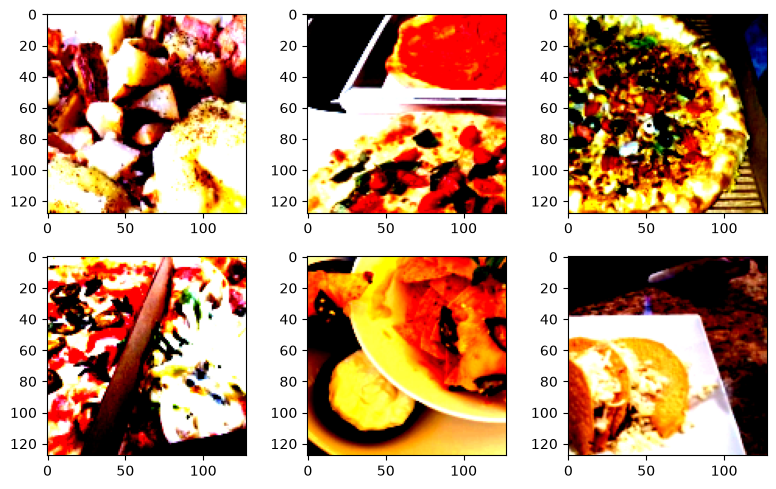

In [ ]:
# Check sizes
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

# Visualize one batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")   # should be [32, 3, 128, 128]
print(f"Labels: {labels}")

fig, axes = plt.subplots(2, 3, figsize=(8, 5))  # 2 rows, 3 cols

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].permute(1, 2, 0))

plt.tight_layout()
plt.show()

## Train Split Sample

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5430065..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5280112..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0996952].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7731092..1.7511113].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.64].


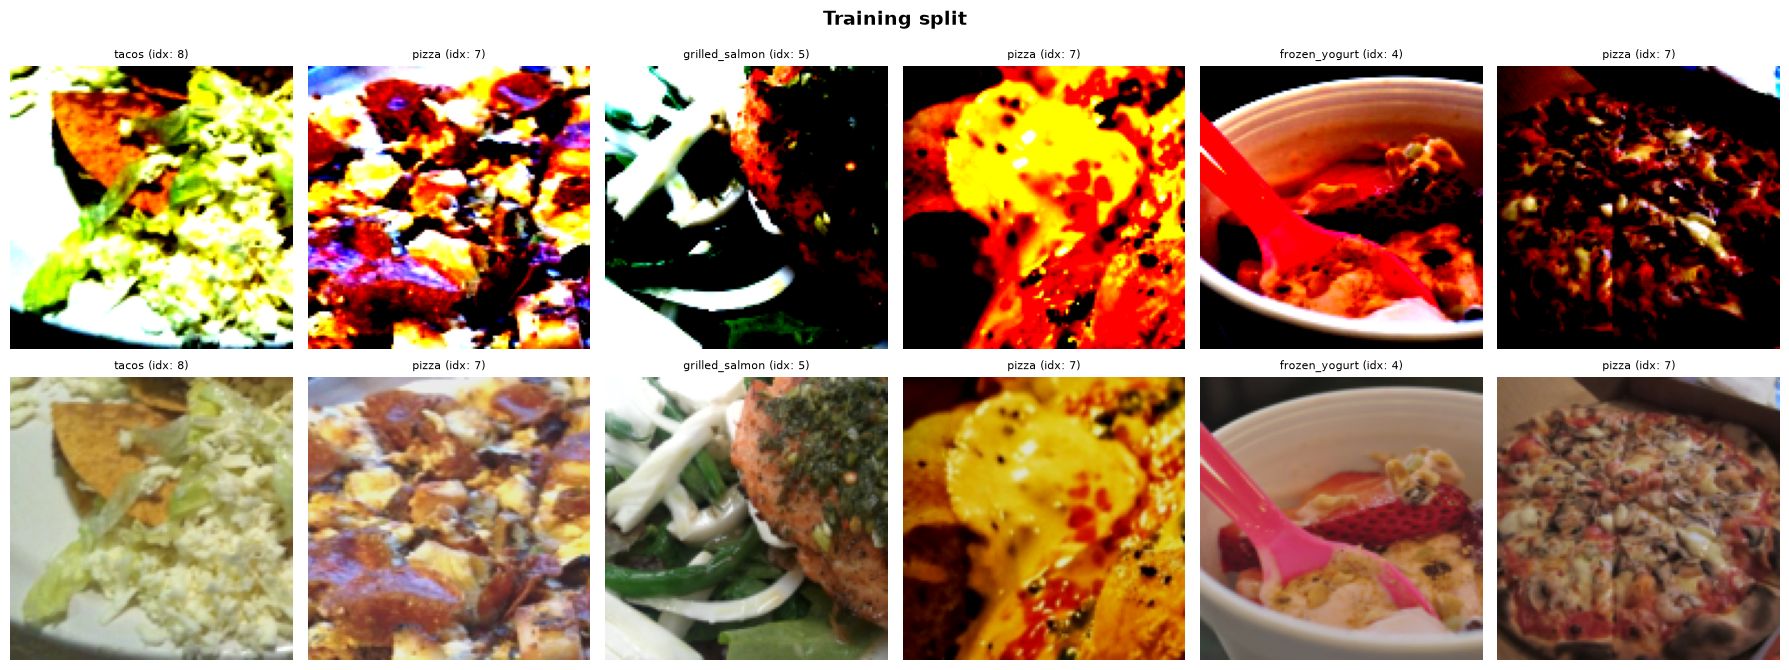

In [ ]:
def show_batch(loader, dataset, title, n=4):
    images, labels = next(iter(loader))
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    images_viewable = (images * std + mean).clamp(0, 1)

    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

    fig, axes = plt.subplots(2, n, figsize=(3*n, 7))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for i in range(n):
        class_name = idx_to_class[labels[i].item()]
        class_idx  = labels[i].item()

        # Top row — raw normalized (transformed)
        ax_top = axes[0][i]
        ax_top.imshow(images[i].permute(1, 2, 0).numpy())
        ax_top.set_title(f"{class_name} (idx: {class_idx})", fontsize=8)
        ax_top.axis("off")
        if i == 0:
            ax_top.set_ylabel("Normalized", fontsize=9, labelpad=6)

        # Bottom row — unnormalized (viewable)
        ax_bot = axes[1][i]
        ax_bot.imshow(images_viewable[i].permute(1, 2, 0).numpy())
        ax_bot.set_title(f"{class_name} (idx: {class_idx})", fontsize=8)
        ax_bot.axis("off")
        if i == 0:
            ax_bot.set_ylabel("Viewable", fontsize=9, labelpad=6)

    plt.tight_layout()
    plt.show()

show_batch(train_loader, train_loader.dataset, "Training split", n=6)

## Validation Split Sample

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..1.015926].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.622571].


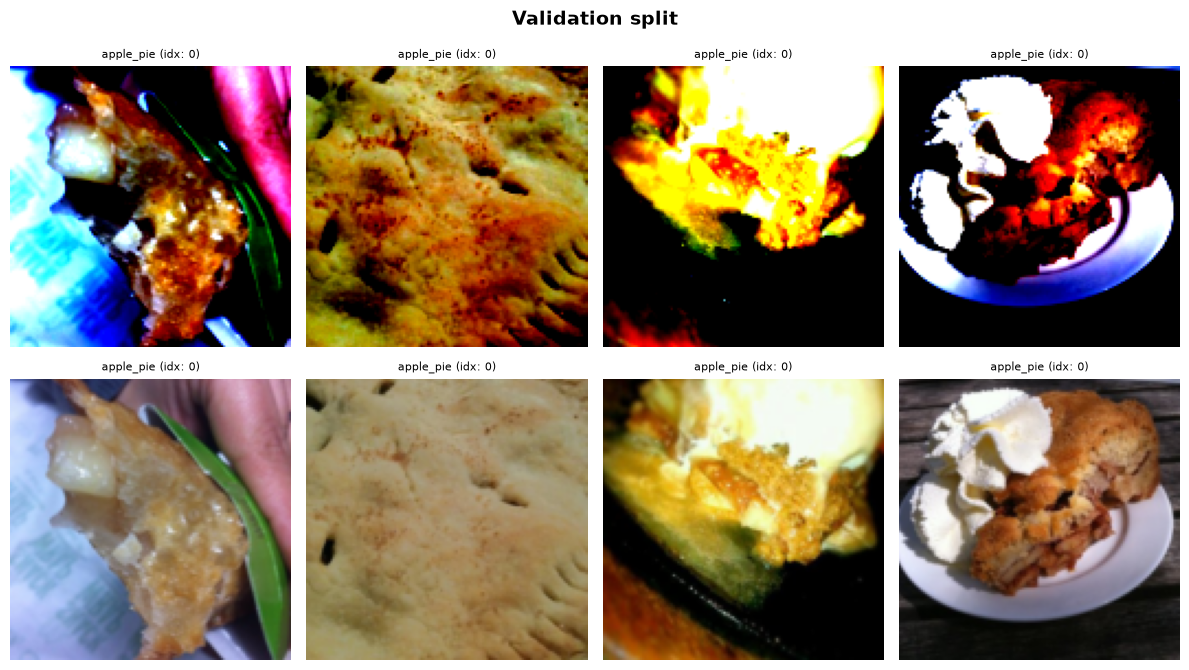

In [24]:
show_batch(val_loader, val_loader.dataset, "Validation split", n=4)